# Question 2 – Edge Detection

### Implement Sobel operator manually using your convolution function

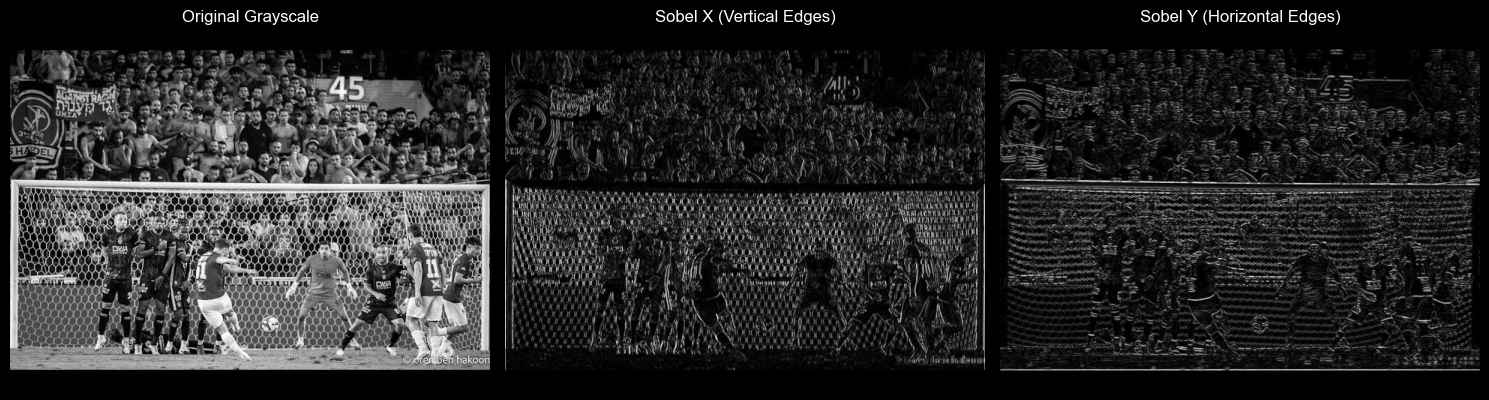

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# The function from quesiton 1
def manual_convolve2d(image, kernel, padding='same', strides=1):
    """
    To have different padding pass an int with the padding you want
    Default padding (same) keeps the image shape
    """
    k_h, k_w = kernel.shape
    h, w = image.shape

    if padding == 'same':
        pad_h = (k_h - 1) // 2
        pad_w = (k_w - 1) // 2
    else:
        pad_h = padding
        pad_w = padding

    padded_h = h + (2 * pad_h)
    padded_w = w + (2 * pad_w)
    padded_image = np.zeros((padded_h, padded_w))

    padded_image[pad_h : pad_h + h, pad_w : pad_w + w] = image

    out_h = (padded_h - k_h) // strides + 1
    out_w = (padded_w - k_w) // strides + 1

    output = np.zeros((out_h, out_w))

    for y in range(out_h):
        for x in range(out_w):
            start_y = y * strides
            end_y = start_y + k_h
            start_x = x * strides
            end_x = start_x + k_w

            roi = padded_image[start_y:end_y, start_x:end_x]
            k = (roi * kernel).sum()

            output[y, x] = k

    return output

image_color = cv2.imread('hapoel.jpg')
image_gray = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

sobel_x_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y_kernel = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

sobel_x_output = manual_convolve2d(image_gray, sobel_x_kernel)
sobel_y_output = manual_convolve2d(image_gray, sobel_y_kernel)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.abs(sobel_x_output), cmap='gray')
plt.title("Sobel X (Vertical Edges)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(np.abs(sobel_y_output), cmap='gray')
plt.title("Sobel Y (Horizontal Edges)")
plt.axis('off')

plt.tight_layout()
plt.show()

### Compute the gradient magnitude and gradient orientation

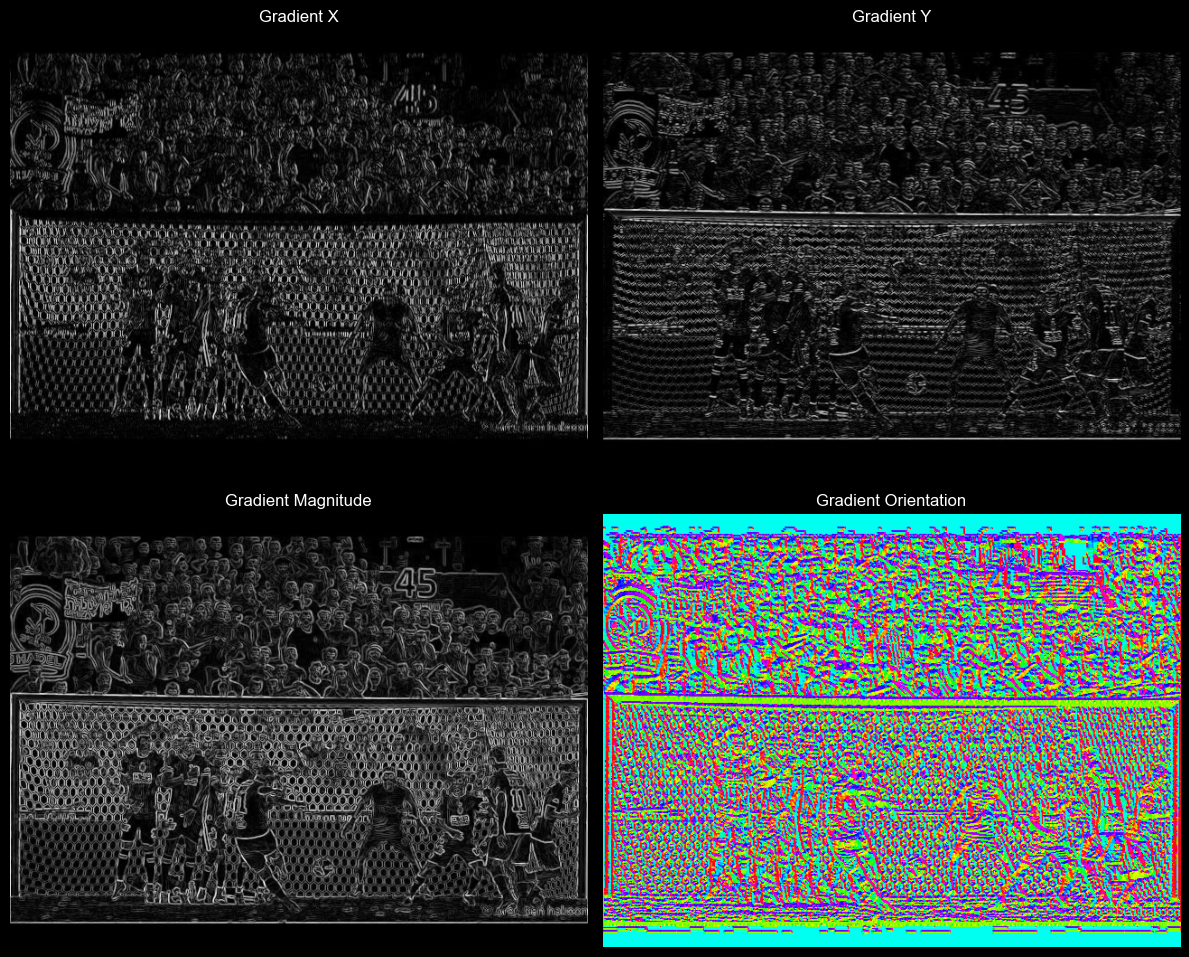

In [13]:
gradient_magnitude = np.sqrt(sobel_x_output**2 + sobel_y_output**2)

# noramalize values between 0-255
magnitude_normalized = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
gradient_orientation = np.arctan2(sobel_y_output, sobel_x_output)

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(np.abs(sobel_x_output), cmap='gray')
plt.title("Gradient X")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(np.abs(sobel_y_output), cmap='gray')
plt.title("Gradient Y")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(magnitude_normalized, cmap='gray')
plt.title("Gradient Magnitude")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(gradient_orientation, cmap='hsv')
plt.title("Gradient Orientation")
plt.axis('off')

plt.tight_layout()
plt.show()

### Compare with results from cv2.Sobel

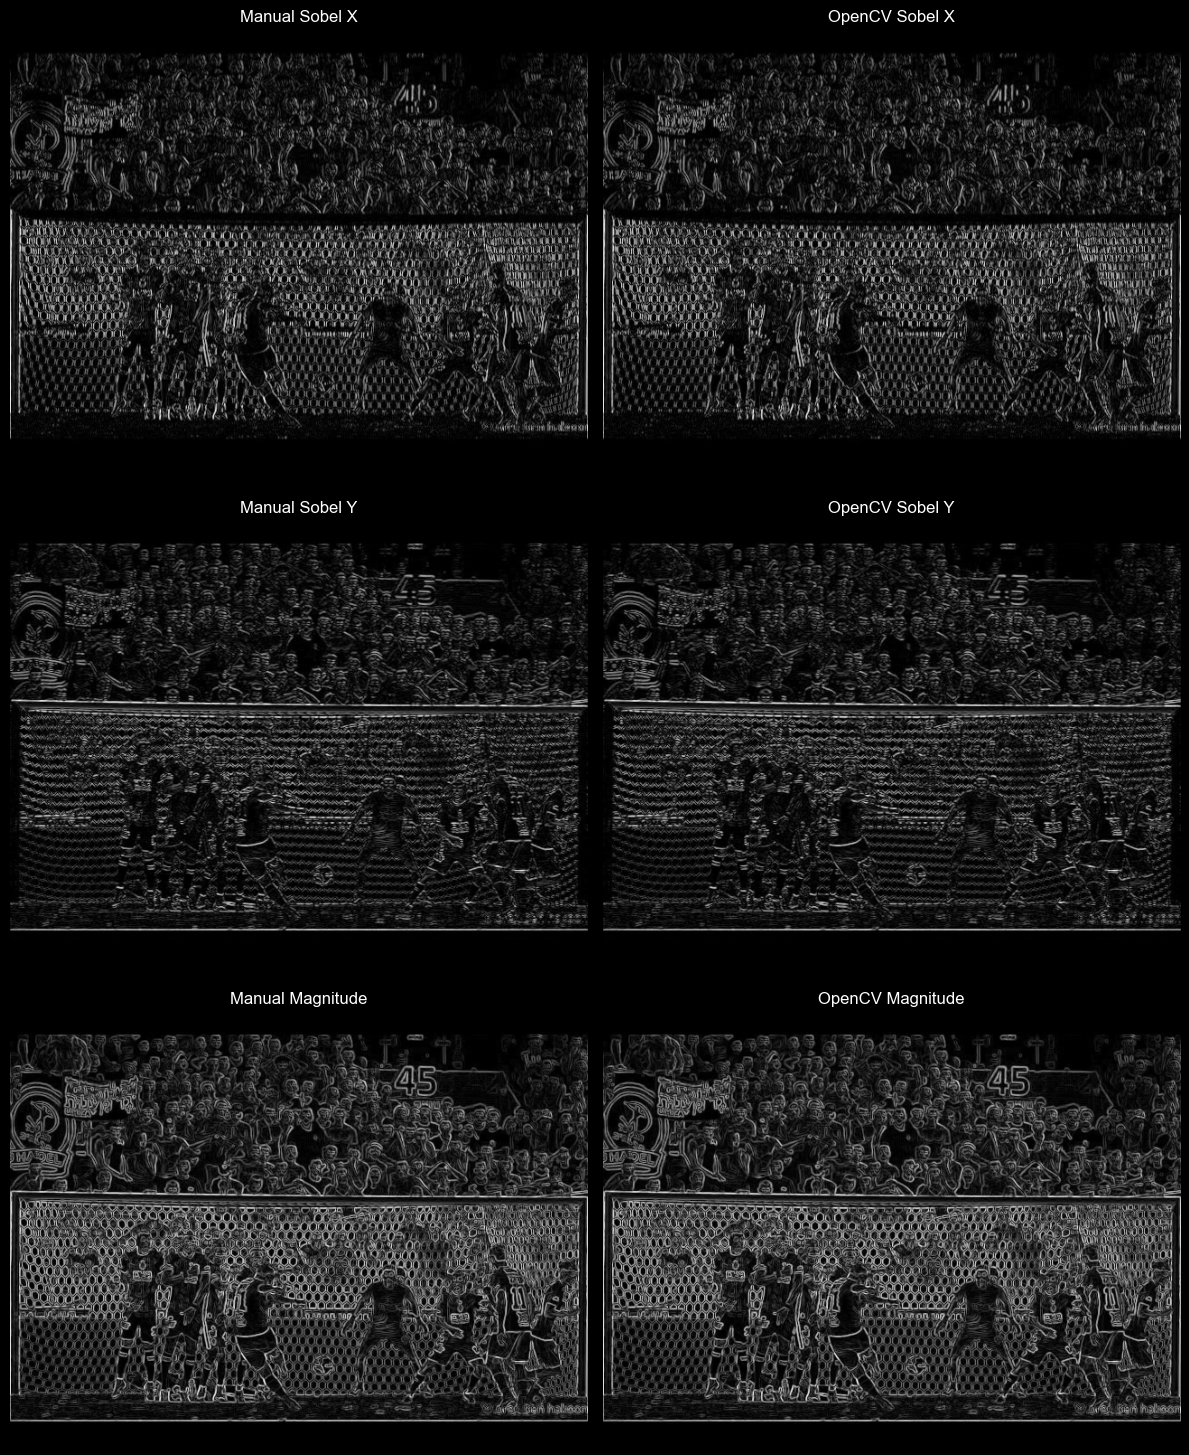

In [15]:
cv_x = cv2.Sobel(image_gray, cv2.CV_64F, 1, 0, ksize=3, borderType=cv2.BORDER_CONSTANT)
cv_y = cv2.Sobel(image_gray, cv2.CV_64F, 0, 1, ksize=3, borderType=cv2.BORDER_CONSTANT)
cv_mag = np.sqrt(cv_x**2 + cv_y**2)

manual_x = sobel_x_output
manual_y = sobel_y_output
manual_mag = magnitude_normalized

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

axes[0, 0].imshow(np.abs(manual_x), cmap='gray')
axes[0, 0].set_title("Manual Sobel X")
axes[0, 0].axis('off')

axes[0, 1].imshow(np.abs(cv_x), cmap='gray')
axes[0, 1].set_title("OpenCV Sobel X")
axes[0, 1].axis('off')

axes[1, 0].imshow(np.abs(manual_y), cmap='gray')
axes[1, 0].set_title("Manual Sobel Y")
axes[1, 0].axis('off')

axes[1, 1].imshow(np.abs(cv_y), cmap='gray')
axes[1, 1].set_title("OpenCV Sobel Y")
axes[1, 1].axis('off')


axes[2, 0].imshow(manual_mag, cmap='gray')
axes[2, 0].set_title("Manual Magnitude")
axes[2, 0].axis('off')

axes[2, 1].imshow(cv_mag, cmap='gray')
axes[2, 1].set_title("OpenCV Magnitude")
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

 ### Include visual comparison and explanation of differences

To my eyes the pictures are almost identical so the manual implementation is very similar to cv2 implementation